In [113]:
import numpy as np
import pandas as pd
import matplotlib

In [114]:
data = pd.read_csv("./input/country_results.csv")

Os dados com que estamos trabalhando referem-se aos resultados de cada país participante da Olimpíada Internacional de Matemática (IMO) ao longo dos anos de 1959 - 2024. Cada linha da tabela abaixo traz informações sobre a participação de um país em uma edição específica da competição. Cada coluna representa um possível dado nesse contexto, sendo eles: 
- ano da edição (year): variável numérica discreta;
- país participante (country): variável categórica nominal;
- quantidade de participantes da equipe (team_size_all): variável numérica discreta;
- quantidade de participantes masculinos da equipe (team_size_male): variável numérica discreta;
- quantidade de participantes femininos da equipe (team_size_female): variável numérica discreta;
- pontuação acumulada da equipe em cada problema respectivo da prova (p1, p2, ..., p7): variável numérica discreta;
- quantidade de medalhas de ouro, prata ou bronze e quantidade de menções honrosas conferidas à equipe (awards_gold, awards_silver, awards_bronze, awards_honorable_mentions): variável numérica discreta;
- nome completo do líder da equipe (leader): variável categórica nominal;
- nome completo do vice-líder da equipe (deputy_leader): variável categórica nominal.


Valores com informações faltantes são marcadas com "NA".

In [115]:
display(data)

,year,country,team_size_all,team_size_male,team_size_female,p1,p2,p3,p4,p5,p6,p7,awards_gold,awards_silver,awards_bronze,awards_honorable_mentions,leader,deputy_leader
0,2024,United States of America,6,5.0,1.0,42.0,41.0,19.0,40.0,35.0,15.0,NaN,5.0,1.0,0.0,0.0,John Berman,Carl Schildkraut
1,2024,People's Republic of ...,6,6.0,0.0,42.0,42.0,31.0,40.0,22.0,13.0,NaN,5.0,1.0,0.0,0.0,Liang Xiao,Yijun Yao
2,2024,Republic of Korea,6,6.0,0.0,42.0,37.0,18.0,42.0,7.0,22.0,NaN,2.0,4.0,0.0,0.0,Suyoung Choi,Hwajong Yoo
3,2024,India,6,6.0,0.0,42.0,34.0,11.0,42.0,28.0,10.0,NaN,4.0,1.0,0.0,1.0,Krishnan Sivasubramanian,Rijul Saini
4,2024,Belarus,6,6.0,0.0,42.0,30.0,10.0,42.0,36.0,5.0,NaN,4.0,0.0,2.0,0.0,David Zmiaikou,Dzmitry Bazyleu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3775,1959,Czechoslovakia,8,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,NaN,Rudolf Zelinka,NaN
3776,1959,Bulgaria,8,6.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,Stoian Budurov,NaN
3777,1959,Poland,8,7.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,Mieczyslaw Czyżykowski,NaN
3778,1959,Union of Soviet Socia...,4,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,NaN,Anatol Mikhailovitch ...,NaN


A fim de possuirmos variáveis de todos os 4 tipos possíveis para esse estudo, iremos derivar duas novas variáveis a partir desses dados:
- proporção de participantes femininos na equipe (female_proportion): variável numérica contínua;
- maturidade da equipe em concentrar-se somente nas fáceis ou garantir pontos nas difíceis (team_approach): variável categórica ordinal.

In [116]:
data["female_proportion"] = data["team_size_female"]/data["team_size_all"]

max = 7*data["team_size_all"]*2
p_easy = (data["p1"]+data["p4"])/max
p_medium = (data["p2"]+data["p5"])/max
p_hard = (data["p3"]+data["p6"])/max

thresholds = [
    (p_easy >= 0.8) & (p_medium >= 0.5) & (p_hard >= 0.2),
    (p_easy >= 0.8) & (p_medium >= 0.5),
    (p_easy >= 0.8),
    (p_easy < 0.8)
]

values = ["Elite", "Regular", "Base", "Incomplete Base"]

data["team_approach"] = pd.Categorical(np.select(thresholds, values, default=None), categories = values[::-1], ordered = True)

*Seção 1.1* Análise univariada das variáveis qualitativa "team_approach" e quantitativa "female_proportion".

Abaixo, observe a distribuição de frequências das abordagens das equipes:

In [117]:
display(pd.DataFrame(data["team_approach"].value_counts(sort=False)))

,count
team_approach,
Incomplete Base,2571
Base,477
Regular,272
Elite,350


Observe agora os valores normalizados:

In [118]:
dfTeamApproachN = pd.DataFrame(data["team_approach"].value_counts(sort = False, normalize = True))
display(dfTeamApproachN)

,proportion
team_approach,
Incomplete Base,0.700545
Base,0.129973
Regular,0.074114
Elite,0.095368


Para melhor visualizarmos essa distribuição, observe o gráfico abaixo. Nele, observamos que é significativamente mais frequente que os países tenham postura de Base Incompleta. É curioso também que mais vezes as equipes tomaram postura de Elite do que posturar Regulares, fugindo à ordenação esperada.

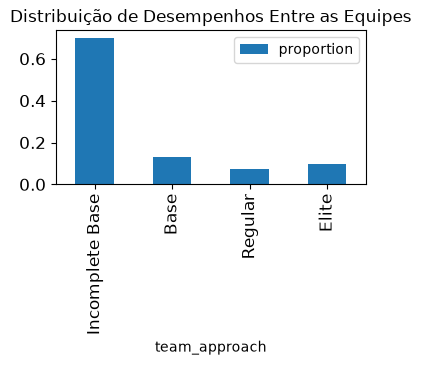

In [119]:
teamApproachPlot = dfTeamApproachN.plot(kind='bar', figsize=(4,2), title='Distribuição de Desempenhos Entre as Equipes',fontsize=12)

Analisando a trajetória adotada por um país de extremo sucesso na competição, a China, observamos como esse país consistentemente conseguiu perfomar como Elite, sem precisar desempenhar nas categorias intermediárias.

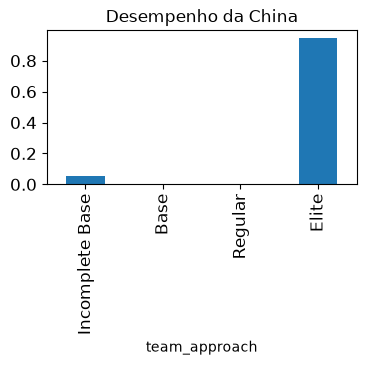

In [120]:
dfChinaApproach = data.loc[data['country'] == "People's Republic of China", "team_approach"].value_counts(sort = False, normalize = True)
chinaApproachPlot = dfChinaApproach.plot(kind='bar', figsize=(4,2), title='Desempenho da China',fontsize=12)

Já o Brasil se distribuiu conforme o gráfico abaixo. Perceba como o país já tem uma distribuição mais equilibrada com o que se espera da ordenação das abordagens, não tendo ainda se desempenhado como Elite.

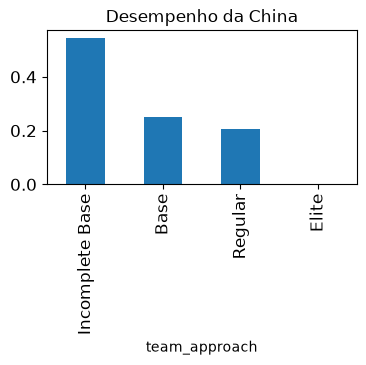

In [ ]:
dfChinaApproach = data.loc[data['country'] == "Brazil", "team_approach"].value_counts(sort = False, normalize = True)
chinaApproachPlot = dfChinaApproach.plot(kind='bar', figsize=(4,2), title='Desempenhodo Brasil',fontsize=12)

Analisemos agora uma variável quantitativa. Na tabela abaixo, observamos como se distribui a proporção de meninas nas equipes, considerando os dados existentes. Cabe ressaltar que os dados anteriores a 2020 são parciais, nos quais nem todas as equipes possuem a informação da proporção de meninas. Percebe-se a enorme quantidade de equipes com até 1/6 de meninas na equipe.

In [124]:
x = data['female_proportion'].dropna()
femaleProportionIn = pd.cut(x, 
                      bins=np.linspace(0,1,7), 
                      labels=[
                          "[0/6 - 1/6]", 
                          "]1/6 - 2/6]", 
                          "]2/6 - 3/6]",
                          "]3/6 - 4/6]", 
                          "]4/6 - 5/6]", 
                          "]5/6 - 6/6]"
                      ], 
                      include_lowest=True,
                  )
display(pd.DataFrame(femaleProportionIn.value_counts(sort = False)))

,count
female_proportion,
[0/6 - 1/6],1127
]1/6 - 2/6],342
]2/6 - 3/6],95
]3/6 - 4/6],18
]4/6 - 5/6],2
]5/6 - 6/6],16


Abaixo, a distribuição normalizada e o gráfico de barras da distribuição:

,proportion
female_proportion,
[0/6 - 1/6],0.704375
]1/6 - 2/6],0.213750
]2/6 - 3/6],0.059375
]3/6 - 4/6],0.011250
]4/6 - 5/6],0.001250
]5/6 - 6/6],0.010000


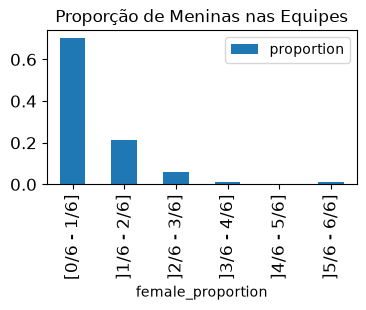

In [129]:
dfFemaleProportionIn = pd.DataFrame(femaleProportionIn.value_counts(sort = False, normalize = True))
display(dfFemaleProportionIn)
femaleProportionInPlot = dfFemaleProportionIn.plot(kind='bar', figsize=(4,2), title='Proporção de Meninas nas Equipes',fontsize=12)